In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import numpy as np
import matplotlib.pyplot as plt
import h5py
import helper_functions as hf
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# add truth labels to loss files

In [26]:
bkg_file = "BKG.h5"
bkg_SB_file = "BKG_SB.h5"
dirs = ["lossEvals","lossEvals_pcaDecorr","lossEvals_pcaDecorr_boxCox",
        "lossEvals_linearDecorr","lossEvals_linearDecorr_boxCox","lossEvals_noDecorr"]
variables = ["mjj","truth_label"]
data = hf.loadData("BKG",variables,dEta_cut=1.3,sideband=False,mode="all")
data_SB = hf.loadData("BKG",variables,dEta_cut=-1,sideband=True,mode="all")

100%|██████████| 80/80 [00:27<00:00,  2.92it/s]


In [27]:
with h5py.File(f"{dirs[0]}/{bkg_file}","r") as f:
    mjj = f["mjj"][()]
with h5py.File(f"{dirs[0]}/{bkg_SB_file}","r") as f:
    mjj_SB = f["mjj"][()]

In [28]:
print(data.shape)
print(mjj.shape)
print(np.all(data[:,0]==mjj))
print(data_SB.shape)
print(mjj_SB.shape)
print(np.all(data_SB[:,0]==mjj_SB))

(7440870, 2)
(7440870,)
True
(2601768, 2)
(2601768,)
True


In [31]:
from tqdm import tqdm
files = [f"{d}/{bkg_file}" for d in dirs]
files_SB = [f"{d}/{bkg_SB_file}" for d in dirs]
for f in files:
    with h5py.File(f,"r+") as fout:
        fout.create_dataset("truth_label",data=data[:,1])
for f in files_SB:
    with h5py.File(f,"r+") as fout:
        fout.create_dataset("truth_label",data=data_SB[:,1])

In [32]:
with h5py.File(f"{dirs[0]}/{bkg_file}","r") as f:
    mjj = f["mjj"][()]
    tl = f["truth_label"][()]
with h5py.File(f"{dirs[0]}/{bkg_SB_file}","r") as f:
    mjj_SB = f["mjj"][()]
    tl_SB = f["truth_label"][()]

# add jet masses to loss files

In [7]:
#files = ["BKG.h5","DATA_SB.h5","BKG_SB.h5","DATA.h5"]
files = ["DATA.h5"]
dirs = ['lossEvals','lossEvals_noDecorr','lossEvals_pcaDecorr','lossEvals_pcaDecorr_boxCox','lossEvals_linearDecorr','lossEvals_linearDecorr_boxCox']
variables = ["mjj","jet1_mass","jet2_mass","truth_label","jet1_btagscore","jet2_btagscore"]
for f in files:
    print(f"Running on {f}")
    sideband = True if "SB" in f else False
    dEta_cut = -1 if "SB" in f else 1.3
    if "DATA" in f:
        data = hf.loadData("DATA",variables,dEta_cut=dEta_cut,sideband=sideband,mode='all')
    elif "BKG" in f:
        data = hf.loadData("BKG",variables,dEta_cut=dEta_cut,sideband=sideband,mode='all')
    mjj = data[:,0]
    toWrite = data[:,1:]
    writeNames = variables[1:]
    for d in dirs:
        with h5py.File(f"{d}/{f}","r+") as fout:
            mjj_orig = fout["mjj"][()]
            if not np.all(mjj==mjj_orig):
                print(f"loaded mjj doesn't match existing for {d}/{f}")
                exit
            for i,v in enumerate(writeNames):
                if v in fout.keys():
                    del fout[v]
                fout.create_dataset(v,data=toWrite[:,i])

Running on DATA.h5


100%|██████████| 40/40 [03:53<00:00,  5.85s/it]


# Add lund weights to files

In [15]:
lund_dir = "/nobackup/users/sambt/CASE_samples/merged/SIGNAL_LUND/"
from samples import signal_map
sig_map = {s:signal_map[s] for s in signal_map.keys() if "RSG" not in s}
toEdit = [f for f in os.listdir('lossEvals') if '.h5' in f and f!='BKG.h5' and f!="BKG_SB.h5" and f!='DATA_SB.h5' and f!='DATA.h5' and "RSG" not in f]
systs = ['lund_weights','lund_weights_stat_var','lund_weights_pt_var','lund_weights_sys_var','lund_weights_matching_unc']
dirs = ['lossEvals']

In [17]:
bad_files = []
bad_files_lund = []
from tqdm import tqdm
for d in dirs:
    for ef in tqdm(toEdit):
        lund_file = lund_dir+sig_map[ef[:-3]]
        ed_file = f"{d}/{ef}"
        with h5py.File(lund_file,"r") as lf:
            deta = lf['jet_kinematics'][:,1]
            mask = np.abs(deta) < 1.3
            lund_mjj = lf['jet_kinematics'][:,0][mask]
        with h5py.File(ed_file,"r") as edf:
            targ_mjj = edf['mjj'][()]
        if not np.all(targ_mjj==lund_mjj):
            print("bad!")
            bad_files.append(ed_file)
            bad_files_lund.append(lund_file)
            test1 = lund_mjj
            test2 = targ_mjj
            continue
        
        with h5py.File(ed_file,"r+") as edf:
            with h5py.File(lund_file,"r") as lf:
                for sys in systs:
                    if sys in edf.keys():
                        del edf[sys]
                    if sys=="lund_weights_matching_unc":
                        edf.create_dataset(sys,data=lf[sys][()])
                    else:
                        edf.create_dataset(sys,data=lf[sys][()][mask])

100%|██████████| 83/83 [04:01<00:00,  2.91s/it]


In [14]:
bad_files

['lossEvals_noDecorr/XYY5000_Y400_Yp170.h5',
 'lossEvals_noDecorr/XYY3000_Y25_Yp25.h5',
 'lossEvals_noDecorr/XYY3000_Y25_Yp400.h5',
 'lossEvals_noDecorr/XYY2000_Y25_Yp80.h5',
 'lossEvals_noDecorr/XYY2000_Y400_Yp80.h5',
 'lossEvals_noDecorr/XYY5000_Y400_Yp400.h5',
 'lossEvals_noDecorr/XYY3000_Y170_Yp170.h5',
 'lossEvals_noDecorr/XYY2000_Y170_Yp400.h5',
 'lossEvals_noDecorr/XYY2000_Y400_Yp25.h5',
 'lossEvals_noDecorr/XYY2000_Y80_Yp400.h5',
 'lossEvals_noDecorr/XYY2000_Y400_Yp400.h5',
 'lossEvals_noDecorr/XYY5000_Y170_Yp170.h5',
 'lossEvals_noDecorr/XYY3000_Y170_Yp25.h5',
 'lossEvals_noDecorr/XYY3000_Y400_Yp25.h5',
 'lossEvals_noDecorr/XYY2000_Y80_Yp80.h5',
 'lossEvals_noDecorr/XYY3000_Y80_Yp25.h5',
 'lossEvals_noDecorr/XYY5000_Y170_Yp80.h5',
 'lossEvals_noDecorr/XYY2000_Y400_Yp170.h5',
 'lossEvals_noDecorr/XYY3000_Y400_Yp400.h5',
 'lossEvals_noDecorr/XYY3000_Y80_Yp400.h5',
 'lossEvals_noDecorr/XYY5000_Y25_Yp170.h5',
 'lossEvals_noDecorr/XYY2000_Y25_Yp25.h5',
 'lossEvals_noDecorr/XYY5000_

In [57]:
f1 = h5py.File("/nobackup/users/sambt/CASE_samples/merged/SIGNAL/XToYYprimeTo4Q_MX5000_MY400_MYprime170_narrow_TuneCP5_13TeV-madgraph-pythia8_TIMBER.h5","r")
f2 = h5py.File("/nobackup/users/sambt/CASE_samples/merged/SIGNAL_LUND/XToYYprimeTo4Q_MX5000_MY400_MYprime170_narrow_TuneCP5_13TeV-madgraph-pythia8_TIMBER_Lund.h5")
f3 = h5py.File("/nobackup/users/sambt/CASE_samples/merged/test.h5","r")

In [58]:
m1 = f1['jet_kinematics'][:,0]
m2 = f2['jet_kinematics'][:,0]
m3 = f3['jet_kinematics'][:,0]

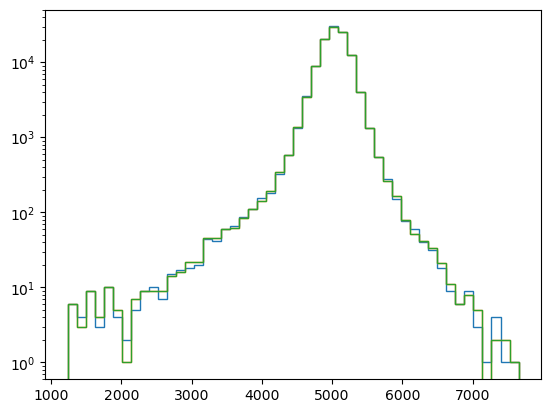

In [59]:
h1,bins,_ = plt.hist(m1,bins=50,histtype='step')
h2,bins,_ = plt.hist(m2,bins=bins,histtype='step')
h3,bins,_ = plt.hist(m3,bins=bins,histtype='step')
plt.yscale('log')

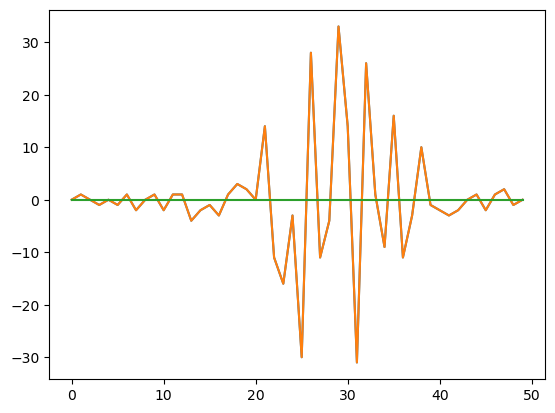

In [61]:
plt.plot(np.arange(len(h1)),h1-h2)
plt.plot(np.arange(len(h1)),h1-h3)
plt.plot(np.arange(len(h1)),h2-h3)